In [10]:
# import os
# import time
# import numpy as np
# import xarray as xr
# from scipy.interpolate import griddata

# # ==========================================
# # 1. Path and Constant Configurations
# # ==========================================
# base_dir = '/nird/datalake/NS11071K/users/yongyub/ORAS5/potential_temperature/1982'
# output_root_dir = '/nird/datalake/NS11071K/users/yongyub/ORAS5/heat_contents'

# year = 1982
# months = range(1, 13)

# # Physical constants for Ocean Heat Content (OHC) calculation
# rho0 = 1025.0  # Reference seawater density (kg/m^3)
# Cp = 3996.0    # Specific heat capacity of seawater (J/(kg*C))

# # Define target regions (Longitude standard: 0 to 360E)
# regions = {
#     'North_Pacific': {'lon_min': 120, 'lon_max': 260, 'lat_min': 30, 'lat_max': 60},
#     'North_Atlantic': {'lon_min': 270, 'lon_max': 360, 'lat_min': 30, 'lat_max': 60}
# }

# # -----------------------------------------------------------------
# # 1.1 Generate Target 1x1 General Grid (Global)
# # -----------------------------------------------------------------
# # Define regular 1-degree intervals for longitude (0.5 to 359.5) and latitude (-89.5 to 89.5)
# target_lon = np.arange(0.5, 360.5, 1.0)
# target_lat = np.arange(-89.5, 90.5, 1.0)
# grid_lon, grid_lat = np.meshgrid(target_lon, target_lat)

# print(f"=== Start 1x1 Regrid & OHC Calculation for {year} ===")
# overall_start = time.time()

# # ==========================================
# # 2. Monthly Loop and Calculation
# # ==========================================
# for month in months:
#     month_start = time.time()
    
#     file_name = f"votemper_control_monthly_highres_3D_{year}{month:02d}_CONS_v0.1.nc"
#     file_path = os.path.join(base_dir, file_name)
    
#     print(f"\n[Processing] File: {file_name}")
    
#     if not os.path.exists(file_path):
#         print(f"  [Error] File not found: {file_path}")
#         continue
        
#     # 2.1 Load dataset
#     t0 = time.time()
#     ds = xr.open_dataset(file_path)
#     print(f"  - File loaded ({time.time() - t0:.2f}s)")
    
#     # 2.2 Detect coordinate names dynamically
#     all_names = list(ds.coords.keys()) + list(ds.keys())
#     lon_name = [v for v in all_names if 'lon' in v.lower() or v.lower() == 'x'][0]
#     lat_name = [v for v in all_names if 'lat' in v.lower() or v.lower() == 'y'][0]
#     depth_name = [v for v in all_names if 'depth' in v.lower() or 'lev' in v.lower() or v.lower() == 'z'][0]
#     temp_name = 'votemper'
    
#     # 2.3 Unit check and conversion (Kelvin to Celsius)
#     T = ds[temp_name]
#     if 'units' in T.attrs and T.attrs['units'] in ['K', 'Kelvin']:
#         T = T - 273.15
#     elif T.max() > 100:
#         T = T - 273.15
        
#     # 2.4 Calculate layer thickness (dz)
#     if 'e3t' in ds:
#         dz = ds['e3t']
#     elif 'deptht_bounds' in ds:
#         dz = ds['deptht_bounds'].diff(dim='bnds').squeeze()
#     else:
#         depth_vals = ds[depth_name].values
#         bounds = np.zeros(len(depth_vals) + 1)
#         bounds[1:-1] = (depth_vals[:-1] + depth_vals[1:]) / 2.0
#         bounds[0] = 0.0
#         bounds[-1] = depth_vals[-1] + (depth_vals[-1] - bounds[-2])
#         dz = xr.DataArray(np.diff(bounds), dims=[depth_name], coords={depth_name: ds[depth_name]})
    
#     # 2.5 Vertical integration for OHC on native curvilinear grid
#     t0 = time.time()
#     ohc_native = (T * dz).sum(dim=depth_name, skipna=True) * rho0 * Cp
    
#     # Flatten source coordinates for interpolation mapping (Standardized to 0-360E)
#     src_lon_flat = (ds[lon_name].values % 360).flatten()
#     src_lat_flat = ds[lat_name].values.flatten()
#     ohc_native_flat = ohc_native.squeeze().values.flatten()
    
#     # Filter out NaN values (landmass) to optimize performance and prevent interpolation artifacts
#     valid_mask = ~np.isnan(ohc_native_flat)
#     points = np.vstack((src_lon_flat[valid_mask], src_lat_flat[valid_mask])).T
#     values = ohc_native_flat[valid_mask]
#     print(f"  - Native OHC integration completed ({time.time() - t0:.2f}s)")
    
#     # 2.6 Horizontal Reprojection: Interpolate onto Global 1x1 General Grid
#     t_interp = time.time()
#     ohc_regridded = griddata(points, values, (grid_lon, grid_lat), method='linear')
#     print(f"  - Global 1x1 horizontal regridding completed ({time.time() - t_interp:.2f}s)")
    
#     # Wrap interpolated array into a clean, standard 1x1 Xarray DataArray
#     # Dimensions now become standard 'lat' and 'lon' instead of non-rectilinear coordinates
#     ohc_1x1 = xr.DataArray(
#         ohc_regridded,
#         dims=['lat', 'lon'],
#         coords={'lat': target_lat, 'lon': target_lon},
#         name='OHC',
#         attrs={
#             'units': 'J/m^2',
#             'long_name': 'Ocean Heat Content per Unit Area on 1x1 Grid'
#         }
#     )
    
#     # 2.7 Region subsetting based on new 1x1 coordinates and exporting
#     for reg_name, b in regions.items():
#         t_reg = time.time()
        
#         # Slicing is now extremely direct and standard using .sel()
#         ohc_region = ohc_1x1.sel(
#             lon=slice(b['lon_min'], b['lon_max']),
#             lat=slice(b['lat_min'], b['lat_max'])
#         )
        
#         # Convert to Dataset format
#         ds_out = ohc_region.to_dataset()
        
#         # Create region-specific directory
#         reg_output_dir = os.path.join(output_root_dir, reg_name)
#         os.makedirs(reg_output_dir, exist_ok=True)
        
#         # Save output
#         output_name = f"{reg_name}_OHC_1x1_{year}{month:02d}.nc"
#         output_path = os.path.join(reg_output_dir, output_name)
#         ds_out.to_netcdf(output_path)
        
#         print(f"  - [{reg_name}] Saved 1x1 output to -> {output_path} ({time.time() - t_reg:.2f}s)")
        
#     print(f"[Done] Monthly elapsed time for month {month:02d}: {time.time() - month_start:.2f}s")

# # ==========================================
# # 3. Overall Performance Summary
# # ==========================================
# print(f"\n=== All processing completed! Total elapsed time: {time.time() - overall_start:.2f}s ===")

=== Start 1x1 Regrid & OHC Calculation for 1982 ===

[Processing] File: votemper_control_monthly_highres_3D_198201_CONS_v0.1.nc
  - File loaded (0.01s)
  - Native OHC integration completed (0.49s)
  - Global 1x1 horizontal regridding completed (33.19s)
  - [North_Pacific] Saved 1x1 output to -> /nird/datalake/NS11071K/users/yongyub/ORAS5/heat_contents/North_Pacific/North_Pacific_OHC_1x1_198201.nc (0.05s)
  - [North_Atlantic] Saved 1x1 output to -> /nird/datalake/NS11071K/users/yongyub/ORAS5/heat_contents/North_Atlantic/North_Atlantic_OHC_1x1_198201.nc (0.01s)
[Done] Monthly elapsed time for month 01: 34.13s

[Processing] File: votemper_control_monthly_highres_3D_198202_CONS_v0.1.nc
  - File loaded (0.01s)
  - Native OHC integration completed (0.50s)
  - Global 1x1 horizontal regridding completed (31.57s)
  - [North_Pacific] Saved 1x1 output to -> /nird/datalake/NS11071K/users/yongyub/ORAS5/heat_contents/North_Pacific/North_Pacific_OHC_1x1_198202.nc (0.01s)
  - [North_Atlantic] Saved 1x


>>> Processing Region: North Pacific ...
  - Past files: 120 | Present files: 120

>>> Processing Region: North Atlantic ...
  - Past files: 120 | Present files: 120

>>> Displaying 2-row x 2-column comprehensive seasonality grid...


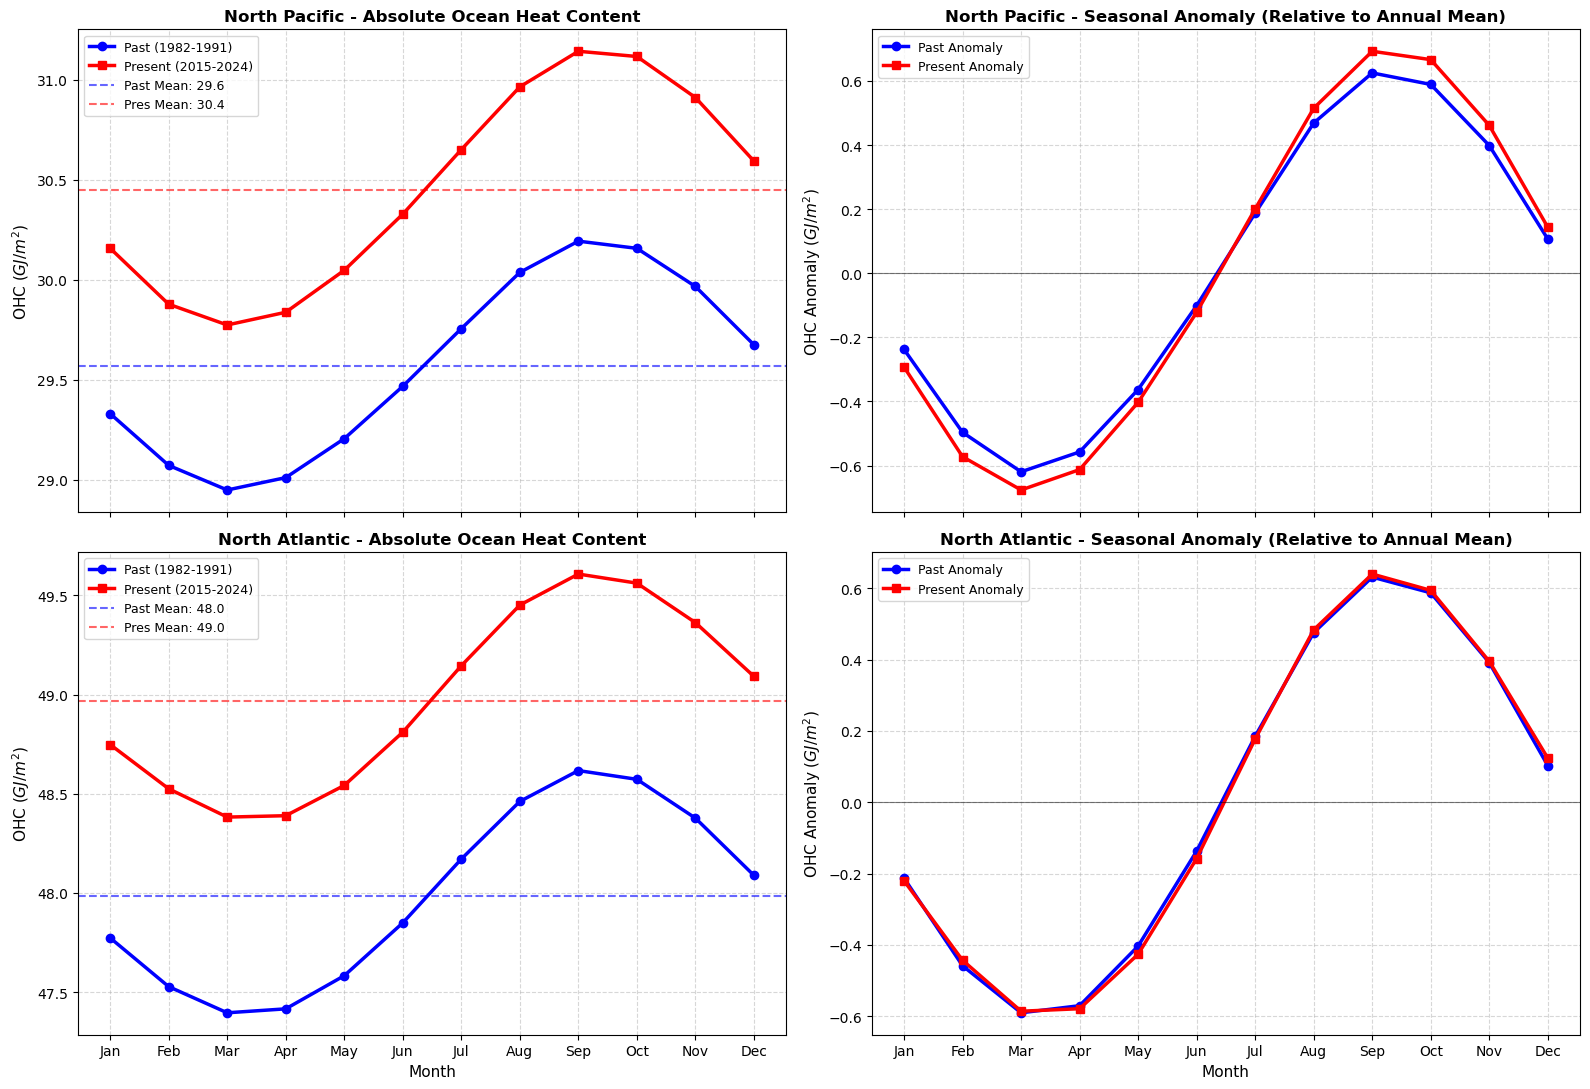


=== ANNUAL MEAN COMPARISON SUMMARY ===
[North Pacific]
  - Past (1982-1991) Annual Mean   : 29.57 GJ/m^2
  - Present (2015-2024) Annual Mean: 30.45 GJ/m^2
  - Baseline Net Warming Change    : +0.88 GJ/m^2

[North Atlantic]
  - Past (1982-1991) Annual Mean   : 47.99 GJ/m^2
  - Present (2015-2024) Annual Mean: 48.97 GJ/m^2
  - Baseline Net Warming Change    : +0.98 GJ/m^2



In [18]:
import os
import glob
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# ==========================================
# 1. Path and Constant Configurations
# ==========================================
# Base directories for both regions
root_dir = '/nird/datalake/NS11071K/users/yongyub/ORAS5/potential_temperature'
regions = ['North_Pacific', 'North_Atlantic']

# Physical constants for Ocean Heat Content (OHC)
rho0 = 1025.0  # Seawater reference density (kg/m^3)
Cp = 3996.0    # Specific heat capacity of seawater (J/(kg*C))

# Define the two 10-year periods for comparison
past_years = range(1982, 1992)      # 1982 ~ 1991 (10 years)
present_years = range(2015, 2025)   # 2015 ~ 2024 (10 years)

def get_file_list(region_name, years_range):
    """Helper function to collect all monthly netCDF files for given region and years"""
    files = []
    reg_dir = os.path.join(root_dir, region_name)
    for yr in years_range:
        # Matches files like North_Pacific_votemper_1x1_198201.nc or North_Atlantic_votemper_1x1_198201.nc
        year_pattern = os.path.join(reg_dir, str(yr), f"{region_name}_votemper_1x1_{yr}*.nc")
        files.extend(sorted(glob.glob(year_pattern)))
    return files

# ==========================================
# 2. OHC Calculation Core Function
# ==========================================
def calculate_ohc_seasonality(file_list):
    """Loads datasets, computes vertical OHC, spatial mean, and 12-month climatology"""
    ds = xr.open_mfdataset(file_list, combine='by_coords', chunks={'time_counter': 1, 'deptht': -1})
    
    T = ds['votemper']
    
    # Calculate layer thickness (dz) from vertical depth centerpoints
    depth = ds['deptht'].values
    bounds = np.zeros(len(depth) + 1)
    bounds[1:-1] = (depth[:-1] + depth[1:]) / 2.0
    bounds[0] = 0.0
    bounds[-1] = depth[-1] + (depth[-1] - bounds[-2])
    dz = xr.DataArray(np.diff(bounds), dims=['deptht'], coords={'deptht': ds['deptht']})
    
    # 2.1 Vertical Integration
    ohc_2d = (T * dz).sum(dim='deptht', skipna=True) * rho0 * Cp
    
    # 2.2 Spatial Mean with Latitude Weighting
    weights = np.cos(np.deg2rad(ds['lat']))
    weights.name = "weights"
    ohc_weighted = ohc_2d.weighted(weights)
    ohc_timeseries = ohc_weighted.mean(dim=['lat', 'lon'], skipna=True)
    
    # 2.3 Compute Climatological Seasonality (12-month cycle)
    ohc_seasonality = ohc_timeseries.groupby('time_counter.month').mean(dim='time_counter')
    
    ohc_seasonality.load()
    ds.close()
    
    return ohc_seasonality

# ==========================================
# 3. Processing Data for All Regions
# ==========================================
results = {}

for reg in regions:
    print(f"\n>>> Processing Region: {reg.replace('_', ' ')} ...")
    past_files = get_file_list(reg, past_years)
    present_files = get_file_list(reg, present_years)
    
    print(f"  - Past files: {len(past_files)} | Present files: {len(present_files)}")
    
    ohc_past = calculate_ohc_seasonality(past_files)
    ohc_present = calculate_ohc_seasonality(present_files)
    
    # Scale to GJ/m^2 and compute anomalies
    past_gj = ohc_past / 1e9
    present_gj = ohc_present / 1e9
    
    mean_past = past_gj.mean()
    mean_present = present_gj.mean()
    
    results[reg] = {
        'past_gj': past_gj, 'present_gj': present_gj,
        'mean_past': mean_past, 'mean_present': mean_present,
        'anomaly_past': past_gj - mean_past,
        'anomaly_present': present_gj - mean_present
    }

# ==========================================
# 4. Render 2-Row x 2-Column Matrix Display
# ==========================================
print("\n>>> Displaying 2-row x 2-column comprehensive seasonality grid...")
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 11), sharex=True)

months_axis = np.arange(1, 13)
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

for r_idx, reg in enumerate(regions):
    res = results[reg]
    title_prefix = "North Pacific" if reg == 'North_Pacific' else "North Atlantic"
    
    # -------------------------------------------------------------
    # Left Column: Absolute Climatological Seasonality
    # -------------------------------------------------------------
    ax_abs = axes[r_idx, 0]
    ax_abs.plot(months_axis, res['past_gj'], marker='o', color='blue', linewidth=2.5, label='Past (1982-1991)')
    ax_abs.plot(months_axis, res['present_gj'], marker='s', color='red', linewidth=2.5, label='Present (2015-2024)')
    
    # Reference annual mean lines
    ax_abs.axhline(res['mean_past'], color='blue', linestyle='--', alpha=0.6, label=f"Past Mean: {res['mean_past']:.1f}")
    ax_abs.axhline(res['mean_present'], color='red', linestyle='--', alpha=0.6, label=f"Pres Mean: {res['mean_present']:.1f}")
    
    ax_abs.set_title(f"{title_prefix} - Absolute Ocean Heat Content", fontsize=12, weight='bold')
    ax_abs.set_ylabel('OHC ($GJ / m^2$)', fontsize=11)
    ax_abs.grid(True, linestyle='--', alpha=0.5)
    ax_abs.legend(fontsize=9, loc='best')
    
    # -------------------------------------------------------------
    # Right Column: Seasonal Anomalies (Relative to own annual mean)
    # -------------------------------------------------------------
    ax_anom = axes[r_idx, 1]
    ax_anom.plot(months_axis, res['anomaly_past'], marker='o', color='blue', linewidth=2.5, label='Past Anomaly')
    ax_anom.plot(months_axis, res['anomaly_present'], marker='s', color='red', linewidth=2.5, label='Present Anomaly')
    ax_anom.axhline(0, color='black', linestyle='-', linewidth=0.8, alpha=0.5)
    
    ax_anom.set_title(f"{title_prefix} - Seasonal Anomaly (Relative to Annual Mean)", fontsize=12, weight='bold')
    ax_anom.set_ylabel('OHC Anomaly ($GJ / m^2$)', fontsize=11)
    ax_anom.grid(True, linestyle='--', alpha=0.5)
    ax_anom.legend(fontsize=9, loc='best')

# Set bottom X-axis labels for both columns
for col_idx in range(2):
    axes[1, col_idx].set_xlabel('Month', fontsize=11)
    axes[1, col_idx].set_xticks(months_axis)
    axes[1, col_idx].set_xticklabels(month_labels)

plt.tight_layout()
plt.show()

# Print text summary report
print("\n=== ANNUAL MEAN COMPARISON SUMMARY ===")
for reg in regions:
    res = results[reg]
    print(f"[{reg.replace('_', ' ')}]")
    print(f"  - Past (1982-1991) Annual Mean   : {res['mean_past'].values:.2f} GJ/m^2")
    print(f"  - Present (2015-2024) Annual Mean: {res['mean_present'].values:.2f} GJ/m^2")
    print(f"  - Baseline Net Warming Change    : {res['mean_present'].values - res['mean_past'].values:+.2f} GJ/m^2\n")

In [19]:
import numpy as np
import xarray as xr

def calculate_asymmetry_indices(ohc_seasonality):
    """
    Performs Fourier Analysis on 12-month OHC climatology 
    to extract A1, A2, phi1, phi2 and compute |DAI| and |PAI|.
    """
    # 1. Ensure data is a 1D array of length 12
    data = ohc_seasonality.values.squeeze()
    if len(data) != 12:
        raise ValueError("Input seasonality must have exactly 12 monthly values.")
        
    # 2. Perform Discrete Fourier Transform (DFT)
    dft_coeffs = np.fft.fft(data)
    
    # N=12 normalization factor (FFT in numpy requires 2/N for non-zero frequencies)
    # Harmonic 1 (Annual cycle): index 1
    # Harmonic 2 (Semi-annual cycle): index 2
    h1 = dft_coeffs[1] * (2.0 / 12.0)
    h2 = dft_coeffs[2] * (2.0 / 12.0)
    
    # 3. Extract Amplitudes (A1, A2)
    A1 = np.abs(h1)
    A2 = np.abs(h2)
    
    # 4. Extract Phases (phi1, phi2) in radians
    # np.angle returns values in range [-pi, pi]. 
    # Using negative sign matches standard standard mathematical representation: cos(omega*t - phi)
    phi1 = -np.angle(h1)
    phi2 = -np.angle(h2)
    
    # 5. Compute Asymmetry Phase Parameter (Theta = 2*phi1 - phi2)
    theta = 2 * phi1 - phi2
    
    # 6. Calculate Magnitude Indices
    amplitude_ratio = A2 / A1
    DAI_mag = amplitude_ratio * np.abs(np.sin(theta))
    PAI_mag = amplitude_ratio * np.abs(np.cos(theta))
    
    return {
        'A1': A1, 'A2': A2, 
        'phi1': np.degrees(phi1) % 360, 'phi2': np.degrees(phi2) % 360, # converted to degrees for display
        'DAI_mag': DAI_mag, 'PAI_mag': PAI_mag
    }

# ==========================================
# Run Asymmetry Analysis for Both Regions
# ==========================================
print("=== Computing Asymmetry Indices (|DAI| & |PAI|) for All Regions ===")

# Loop through the pre-computed results from the 2-row x 2-column step
for reg in ['North_Pacific', 'North_Atlantic']:
    reg_label = reg.replace('_', ' ')
    res = results[reg]
    
    # Pass the standard 12-month climatology (from results dictionary) to the function
    idx_past = calculate_asymmetry_indices(res['past_gj'] * 1e9)     # convert back to J/m^2 for uniform function handling
    idx_present = calculate_asymmetry_indices(res['present_gj'] * 1e9)
    
    # Print Structured Results Table per Region
    print("\n" + "="*55)
    print(f"  [ REGION: {reg_label.upper()} ]")
    print("="*55)
    print(f"{'Metric':<15} | {'Past (1982-1991)':<18} | {'Present (2015-2024)':<18}")
    print("-"*55)
    print(f"{'A1 (Annual)':<15} | {idx_past['A1']/1e9:16.4f} | {idx_present['A1']/1e9:16.4f} GJ/m^2")
    print(f"{'A2 (Semi-Ann)':<15} | {idx_past['A2']/1e9:16.4f} | {idx_present['A2']/1e9:16.4f} GJ/m^2")
    print(f"{'A2 / A1 Ratio':<15} | {idx_past['A2']/idx_past['A1']:16.4f} | {idx_present['A2']/idx_present['A1']:16.4f}")
    print(f"{'phi1 (deg)':<15} | {idx_past['phi1']:16.2f}° | {idx_present['phi1']:16.2f}°")
    print(f"{'phi2 (deg)':<15} | {idx_past['phi2']:16.2f}° | {idx_present['phi2']:16.2f}°")
    print("-"*55)
    print(f"{'|DAI| Magnitude':<15} | \033[1;34m{idx_past['DAI_mag']:16.4f}\033[0m | \033[1;31m{idx_present['DAI_mag']:16.4f}\033[0m")
    print(f"{'|PAI| Magnitude':<15} | \033[1;34m{idx_past['PAI_mag']:16.4f}\033[0m | \033[1;31m{idx_present['PAI_mag']:16.4f}\033[0m")
    print("="*55)

=== Computing Asymmetry Indices (|DAI| & |PAI|) for All Regions ===

  [ REGION: NORTH PACIFIC ]
Metric          | Past (1982-1991)   | Present (2015-2024)
-------------------------------------------------------
A1 (Annual)     |           0.6188 |           0.6921 GJ/m^2
A2 (Semi-Ann)   |           0.0210 |           0.0378 GJ/m^2
A2 / A1 Ratio   |           0.0339 |           0.0547
phi1 (deg)      |           249.13° |           249.45°
phi2 (deg)      |           205.92° |           207.57°
-------------------------------------------------------
|DAI| Magnitude |           0.0314 |           0.0509
|PAI| Magnitude |           0.0129 |           0.0199

  [ REGION: NORTH ATLANTIC ]
Metric          | Past (1982-1991)   | Present (2015-2024)
-------------------------------------------------------
A1 (Annual)     |           0.6158 |           0.6222 GJ/m^2
A2 (Semi-Ann)   |           0.0188 |           0.0255 GJ/m^2
A2 / A1 Ratio   |           0.0305 |           0.0410
phi1 (deg)     

>>> Computing Annual A2/A1 Ratio Timeseries (1982-2024)...
  - Processing Region: North Pacific
  - Processing Region: North Atlantic

>>> Plotting unified A2/A1 ratio timeseries...


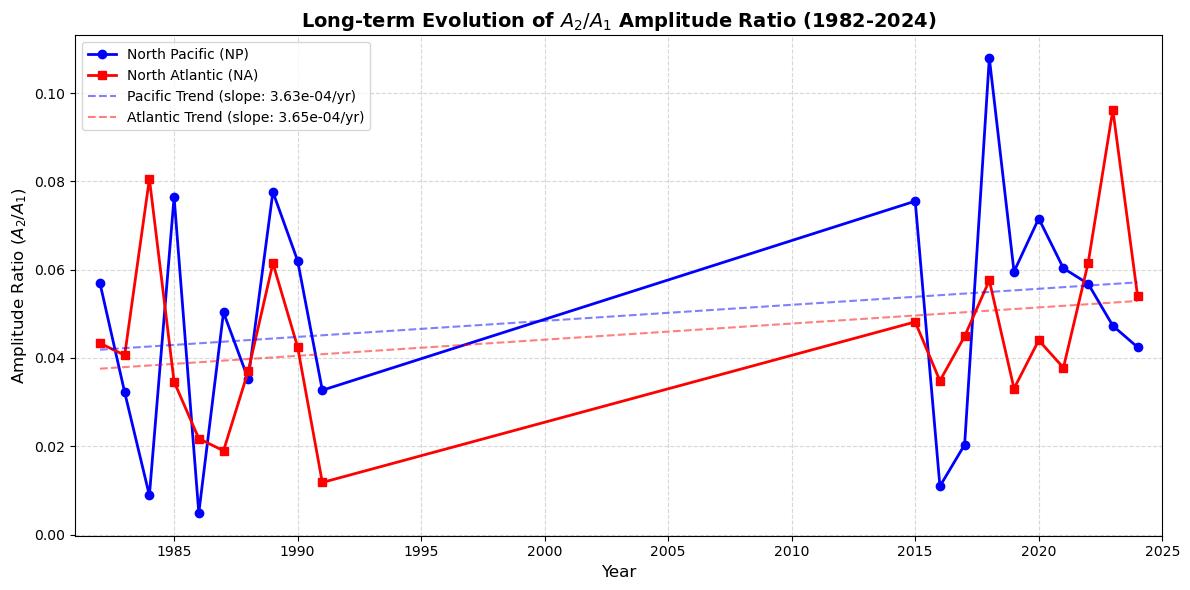

In [20]:
import os
import glob
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# ==========================================
# 1. Path and Multi-Year Configurations
# ==========================================
root_dir = '/nird/datalake/NS11071K/users/yongyub/ORAS5/potential_temperature'
regions = ['North_Pacific', 'North_Atlantic']

all_years = range(1982, 2025)  # 1982 ~ 2024 (43 years)

# Physical constants for Ocean Heat Content
rho0 = 1025.0
Cp = 3996.0

def get_single_year_files(region_name, target_year):
    """Collects exactly 12 monthly files for a specific year and region"""
    reg_dir = os.path.join(root_dir, region_name)
    year_pattern = os.path.join(reg_dir, str(target_year), f"{region_name}_votemper_1x1_{target_year}*.nc")
    return sorted(glob.glob(year_pattern))

# Initialize storage for timeseries
ratio_timeseries = {reg: [] for reg in regions}
valid_years = {reg: [] for reg in regions}

# ==========================================
# 2. Annual Loop for Fourier Ratio Extraction
# ==========================================
print(">>> Computing Annual A2/A1 Ratio Timeseries (1982-2024)...")

for reg in regions:
    print(f"  - Processing Region: {reg.replace('_', ' ')}")
    
    for yr in all_years:
        files = get_single_year_files(reg, yr)
        
        # Check if a full year (12 months) of data exists to perform valid annual FFT
        if len(files) != 12:
            continue
            
        # Open 12 months for the single year
        ds = xr.open_mfdataset(files, combine='by_coords', chunks={'time_counter': 1, 'deptht': -1})
        
        # Layer thickness (dz)
        depth = ds['deptht'].values
        bounds = np.zeros(len(depth) + 1)
        bounds[1:-1] = (depth[:-1] + depth[1:]) / 2.0
        bounds[0] = 0.0
        bounds[-1] = depth[-1] + (depth[-1] - bounds[-2])
        dz = xr.DataArray(np.diff(bounds), dims=['deptht'], coords={'deptht': ds['deptht']})
        
        # Calculate Spatial Area-Weighted Mean Timeseries for the 12 months
        ohc_2d = (ds['votemper'] * dz).sum(dim='deptht', skipna=True) * rho0 * Cp
        weights = np.cos(np.deg2rad(ds['lat']))
        weights.name = "weights"
        ohc_1d = ohc_2d.weighted(weights).mean(dim=['lat', 'lon'], skipna=True).load()
        
        ds.close()
        
        # Perform FFT on the 12-month array
        data_12months = ohc_1d.values.squeeze()
        dft_coeffs = np.fft.fft(data_12months)
        
        # Extract Amplitudes for Harmonic 1 and Harmonic 2
        A1 = np.abs(dft_coeffs[1] * (2.0 / 12.0))
        A2 = np.abs(dft_coeffs[2] * (2.0 / 12.0))
        
        # Compute the ratio and store
        annual_ratio = A2 / A1
        ratio_timeseries[reg].append(annual_ratio)
        valid_years[reg].append(yr)

# ==========================================
# 3. Single-Panel Comparison Plot
# ==========================================
print("\n>>> Plotting unified A2/A1 ratio timeseries...")
plt.figure(figsize=(12, 6))

# Plot North Pacific (NP)
plt.plot(valid_years['North_Pacific'], ratio_timeseries['North_Pacific'], 
         marker='o', color='blue', linewidth=2, label='North Pacific (NP)')

# Plot North Atlantic (NA)
plt.plot(valid_years['North_Atlantic'], ratio_timeseries['North_Atlantic'], 
         marker='s', color='red', linewidth=2, label='North Atlantic (NA)')

# Add linear trendlines to see long-term structural changes
for reg, color in zip(regions, ['blue', 'red']):
    x = np.array(valid_years[reg])
    y = np.array(ratio_timeseries[reg])
    if len(x) > 0:
        slope, intercept = np.polyfit(x, y, 1)
        plt.plot(x, slope*x + intercept, color=color, linestyle='--', alpha=0.5, 
                 label=f"{reg.split('_')[1]} Trend (slope: {slope:.2e}/yr)")

# Plot adjustments
plt.title('Long-term Evolution of $A_2 / A_1$ Amplitude Ratio (1982-2024)', fontsize=14, weight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Amplitude Ratio ($A_2 / A_1$)', fontsize=12)
plt.xlim(1981, 2025)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=10, loc='best')

plt.tight_layout()
plt.show()

In [16]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# ==========================================
# 1. Load 10-Year Datasets (Using existing file lists from prior cells)
# ==========================================
print(">>> Loading full 4D datasets for grid-point analysis...")
ds_past = xr.open_mfdataset(past_files, combine='by_coords', chunks={'time_counter': 1, 'deptht': -1})
ds_present = xr.open_mfdataset(present_files, combine='by_coords', chunks={'time_counter': 1, 'deptht': -1})

# Extract horizontal coordinates
lon = ds_past['lon'].values
lat = ds_past['lat'].values
ny, nx = len(lat), len(lon)

# Calculate layer thickness (dz)
depth = ds_past['deptht'].values
bounds = np.zeros(len(depth) + 1)
bounds[1:-1] = (depth[:-1] + depth[1:]) / 2.0
bounds[0] = 0.0
bounds[-1] = depth[-1] + (depth[-1] - bounds[-2])
dz = xr.DataArray(np.diff(bounds), dims=['deptht'], coords={'deptht': ds_past['deptht']})

# Calculate 2D OHC map time-series (skipna=True properly retains land mask)
print("  - Computing vertical integration for each grid point...")
ohc_past_2d = (ds_past['votemper'] * dz).sum(dim='deptht', skipna=True) * rho0 * Cp
ohc_present_2d = (ds_present['votemper'] * dz).sum(dim='deptht', skipna=True) * rho0 * Cp

# Compute 12-month climatology maps (resulting shape: 12 x lat x lon)
print("  - Generating 12-month climatology grids...")
clim_past = ohc_past_2d.groupby('time_counter.month').mean(dim='time_counter').load()
clim_present = ohc_present_2d.groupby('time_counter.month').mean(dim='time_counter').load()

ds_past.close()
ds_present.close()

# ==========================================
# 2. Grid-Point FFT and Asymmetry Extraction
# ==========================================
def compute_asymmetry_maps(clim_grid):
    """Vectorized calculation of |DAI| and |PAI| maps using numpy FFT"""
    # Shape transformation: (12, lat, lon) -> (12, lat*lon)
    data_3d = clim_grid.values
    data_flat = data_3d.reshape(12, -1)
    
    # Store land mask to restore shape later (where annual mean is NaN)
    land_mask = np.isnan(data_flat.mean(axis=0))
    
    # Fill NaNs temporarily with 0 to prevent FFT corruption on land cells
    data_flat_filled = np.nan_to_num(data_flat, nan=0.0)
    
    # Apply 1D FFT along the monthly axis (axis=0)
    dft_coeffs = np.fft.fft(data_flat_filled, axis=0)
    
    # Harmonic normalization (2 / N)
    h1 = dft_coeffs[1, :] * (2.0 / 12.0)
    h2 = dft_coeffs[2, :] * (2.0 / 12.0)
    
    A1 = np.abs(h1)
    A2 = np.abs(h2)
    
    phi1 = -np.angle(h1)
    phi2 = -np.angle(h2)
    
    theta = 2 * phi1 - phi2
    
    # Avoid zero-division errors over extreme land/missing grids safely
    with np.errstate(divide='ignore', invalid='ignore'):
        amp_ratio = A2 / A1
        dai = amp_ratio * np.abs(np.sin(theta))
        pai = amp_ratio * np.abs(np.cos(theta))
    
    # Re-apply the original ocean-land mask
    dai[land_mask] = np.nan
    pai[land_mask] = np.nan
    
    # Reshape back to standard 2D spatial grid maps
    return dai.reshape(ny, nx), pai.reshape(ny, nx)

print("\n>>> Executing spatial Fourier transform maps...")
dai_past, pai_past = compute_asymmetry_maps(clim_past)
dai_present, pai_present = compute_asymmetry_maps(clim_present)

# Calculate the differences (Present minus Past)
dai_diff = dai_present - dai_past
pai_diff = pai_present - pai_past

>>> Loading full 4D datasets for grid-point analysis...
  - Computing vertical integration for each grid point...
  - Generating 12-month climatology grids...

>>> Executing spatial Fourier transform maps...


>>> Visualizing 3x2 Asymmetry Spatial Matrix with Parula Colormap...


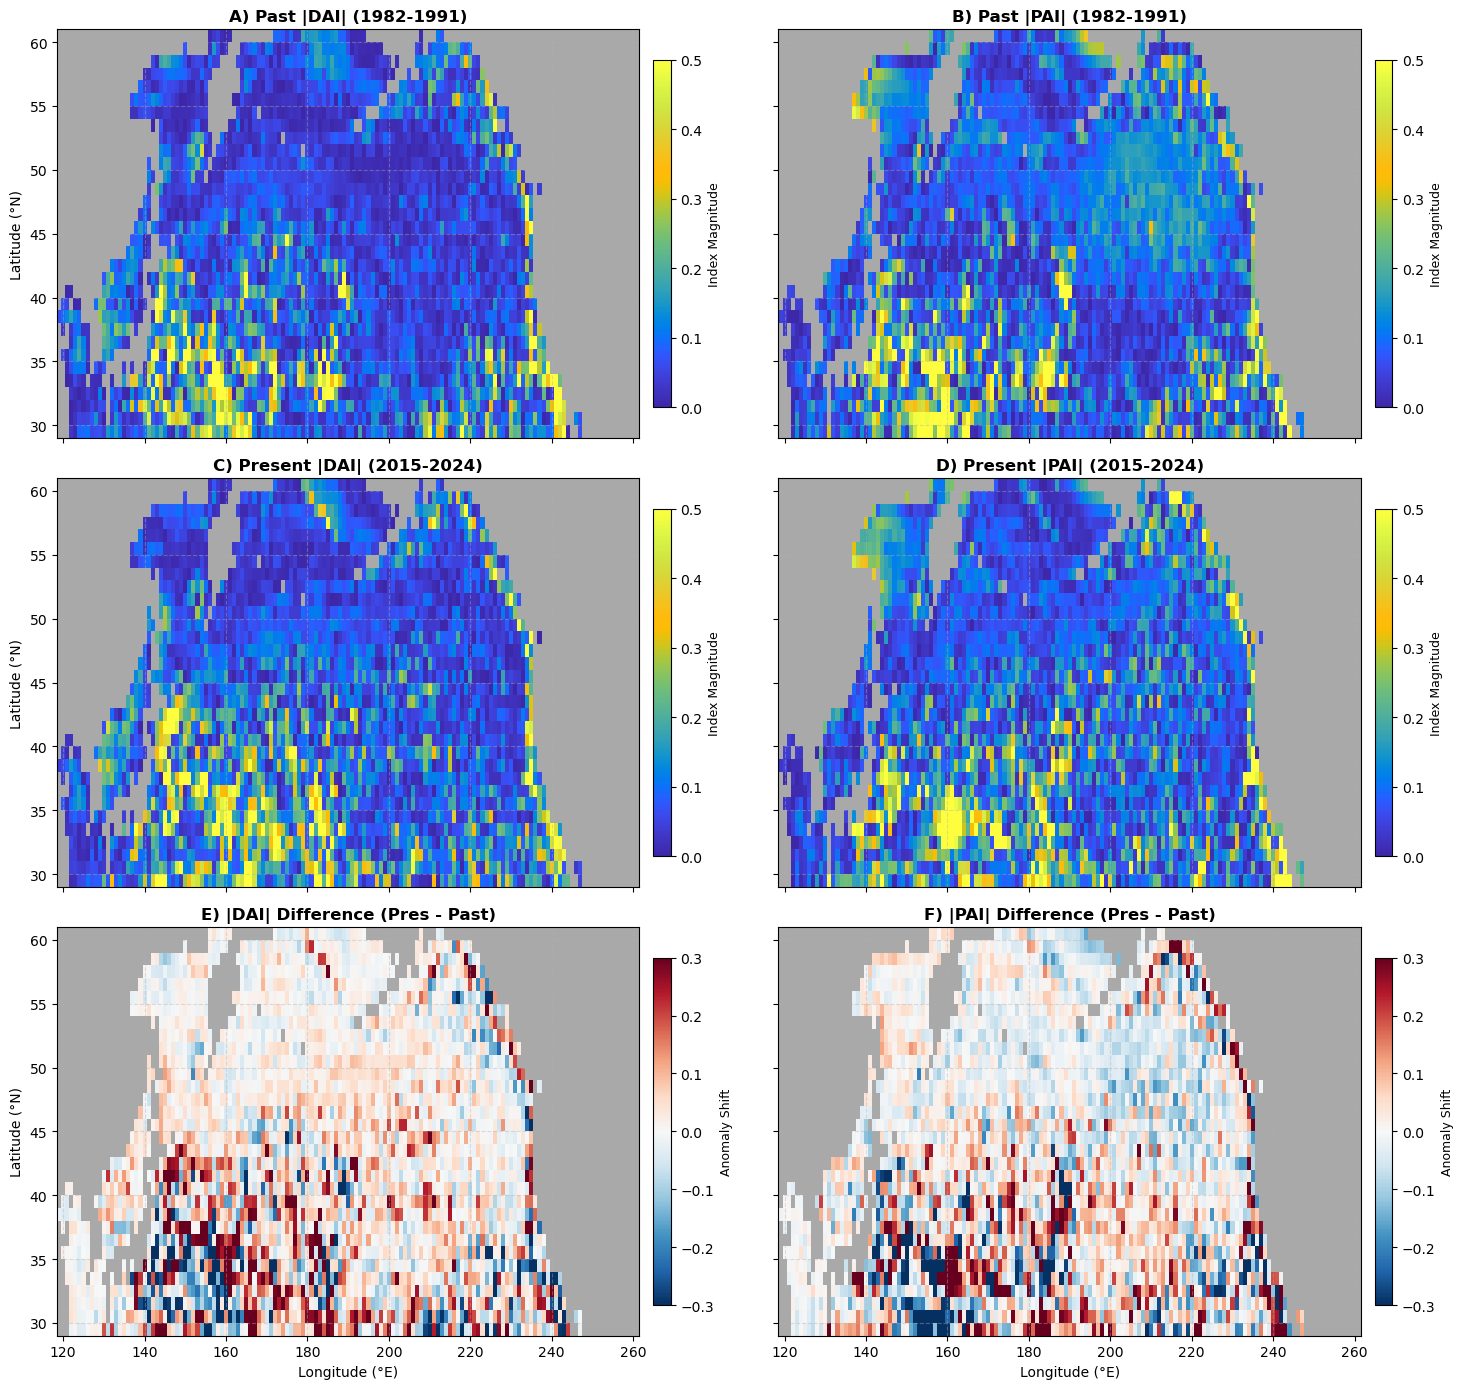

In [22]:
# ==========================================
# 3. Create Custom Parula Colormap & Render Matrix
# ==========================================
print(">>> Visualizing 3x2 Asymmetry Spatial Matrix with Parula Colormap...")

# 3.1 Define Custom Parula RGB Data (MATLAB Standard)
from matplotlib.colors import LinearSegmentedColormap

parula_data = [
    [0.2422, 0.1504, 0.6603], [0.2444, 0.1793, 0.7107], [0.2464, 0.2062, 0.7621],
    [0.2464, 0.2336, 0.8166], [0.2406, 0.2631, 0.8735], [0.2243, 0.2974, 0.9328],
    [0.1925, 0.3372, 0.9852], [0.1345, 0.3842, 0.9996], [0.0637, 0.4337, 0.9822],
    [0.0150, 0.4795, 0.9429], [0.0076, 0.5204, 0.8936], [0.0381, 0.5557, 0.8430],
    [0.0886, 0.5855, 0.7960], [0.1437, 0.6111, 0.7523], [0.1966, 0.6338, 0.7115],
    [0.2448, 0.6548, 0.6724], [0.2878, 0.6749, 0.6336], [0.3275, 0.6946, 0.5941],
    [0.3662, 0.7137, 0.5529], [0.4068, 0.7317, 0.5085], [0.4526, 0.7481, 0.4593],
    [0.5061, 0.7621, 0.4035], [0.5694, 0.7725, 0.3396], [0.6433, 0.7785, 0.2666],
    [0.7275, 0.7789, 0.1856], [0.8193, 0.7719, 0.1065], [0.9120, 0.7561, 0.0453],
    [0.9873, 0.7384, 0.0248], [0.9959, 0.7337, 0.0415], [0.9806, 0.7445, 0.0766],
    [0.9507, 0.7628, 0.1171], [0.9150, 0.7854, 0.1557], [0.8809, 0.8105, 0.1895],
    [0.8533, 0.8369, 0.2173], [0.8339, 0.8637, 0.2384], [0.8242, 0.8904, 0.2530],
    [0.8258, 0.9163, 0.2618], [0.8398, 0.9404, 0.2657], [0.8664, 0.9619, 0.2657],
    [0.9044, 0.9800, 0.2625], [0.9515, 0.9933, 0.2570], [0.9965, 0.9977, 0.2443]
]
parula_cmap = LinearSegmentedColormap.from_list('parula', parula_data, N=256)
diff_cmap = 'RdBu_r'

# 3.2 Main Figure Framing
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 14), sharex=True, sharey=True)
lon_grid, lat_grid = np.meshgrid(lon, lat)

# Unified Range Setup
vmax_idx = 0.5    # Modified: strictly unified range cap (0 to 0.5)
vmax_diff = 0.3

# Subplot rendering mapping array configurations
plots_config = [
    # Row 1: Past State
    {'data': dai_past,    'ax': axes[0, 0], 'cmap': parula_cmap, 'vmin': 0.0,         'vmax': vmax_idx,  'title': 'A) Past |DAI| (1982-1991)'},
    {'data': pai_past,    'ax': axes[0, 1], 'cmap': parula_cmap, 'vmin': 0.0,         'vmax': vmax_idx,  'title': 'B) Past |PAI| (1982-1991)'},
    # Row 2: Present State
    {'data': dai_present, 'ax': axes[1, 0], 'cmap': parula_cmap, 'vmin': 0.0,         'vmax': vmax_idx,  'title': 'C) Present |DAI| (2015-2024)'},
    {'data': pai_present, 'ax': axes[1, 1], 'cmap': parula_cmap, 'vmin': 0.0,         'vmax': vmax_idx,  'title': 'D) Present |PAI| (2015-2024)'},
    # Row 3: Climate Change Shift (Present - Past)
    {'data': dai_diff,    'ax': axes[2, 0], 'cmap': diff_cmap,   'vmin': -vmax_diff, 'vmax': vmax_diff, 'title': 'E) |DAI| Difference (Pres - Past)'},
    {'data': pai_diff,    'ax': axes[2, 1], 'cmap': diff_cmap,   'vmin': -vmax_diff, 'vmax': vmax_diff, 'title': 'F) |PAI| Difference (Pres - Past)'}
]

for p in plots_config:
    ax = p['ax']
    mesh = ax.pcolormesh(lon_grid, lat_grid, p['data'], cmap=p['cmap'], vmin=p['vmin'], vmax=p['vmax'], shading='auto')
    ax.set_title(p['title'], fontsize=12, weight='bold')
    
    # Attach optimized colorbar to each individual panel axis
    cbar = fig.colorbar(mesh, ax=ax, orientation='vertical', pad=0.02, shrink=0.85)
    if 'Difference' in p['title']:
        cbar.set_label('Anomaly Shift', fontsize=9)
    else:
        cbar.set_label('Index Magnitude', fontsize=9)

# Standardize axis decorations for the entire matrix frame
for ax in axes.flatten():
    ax.set_facecolor('darkgray') # Highlights landmask areas beautifully
    ax.grid(True, linestyle='--', alpha=0.4)

# Apply specific labels only to boundary edges to keep plot uncluttered
for row in range(3):
    axes[row, 0].set_ylabel('Latitude (°N)', fontsize=10)
for col in range(2):
    axes[2, col].set_xlabel('Longitude (°E)', fontsize=10)

plt.tight_layout()
plt.show()

>>> Extracting seasonal cycle for single grid point [160.0E, 30.0N]...


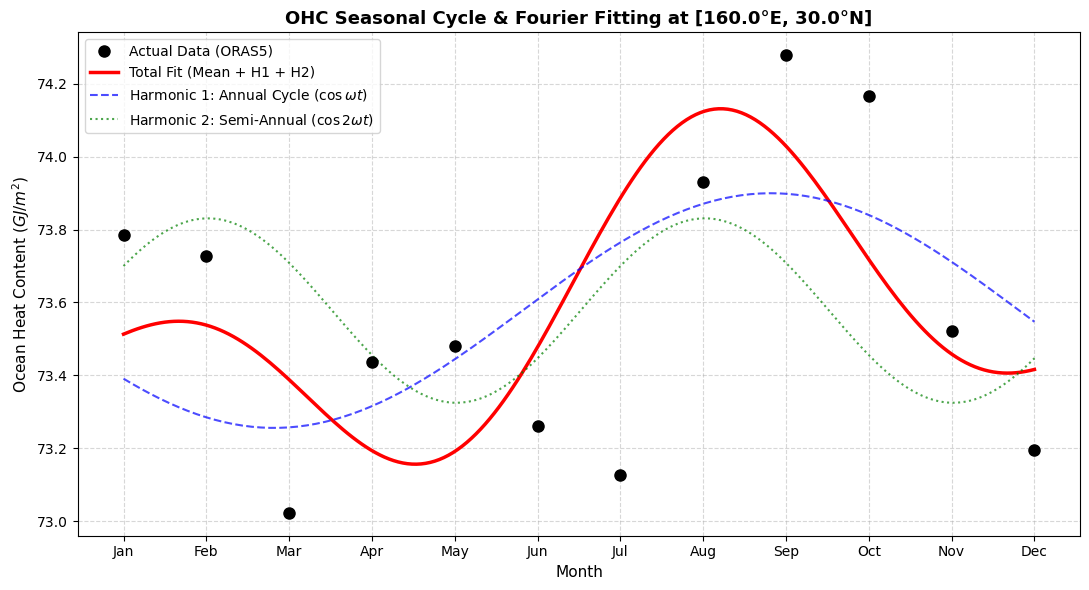


=== DIAGNOSTIC PARAMETERS ===
  - Annual Amplitude (A1)     : 0.322 GJ/m^2
  - Semi-Annual Amplitude (A2): 0.253 GJ/m^2
  - Amplitude Ratio (A2/A1)   : 0.7858
  - Asymmetry Phase (Theta)   : 47.90°
  - Calculated |DAI| Magnitude: 0.5831
  - Calculated |PAI| Magnitude: 0.5268


In [23]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# ==========================================
# 1. Target Grid Point Selection (160E, 30N)
# ==========================================
target_lon = 160.0
target_lat = 30.0

print(f">>> Extracting seasonal cycle for single grid point [{target_lon}E, {target_lat}N]...")

# Extract timeseries at the exact grid cell (using .sel with method='nearest' just in case)
# We will analyze the 'Present' period (2015-2024) as an example.
# If you want to check the Past period, simply swap 'clim_present' with 'clim_past'.
point_data = clim_present.sel(lon=target_lon, lat=target_lat, method='nearest').values

# 12-month coordinates
months = np.arange(1, 13)

# ==========================================
# 2. Fourier Analysis & Continuous Reconstruction
# ==========================================
# Compute FFT
dft_coeffs = np.fft.fft(point_data)

# Mean state (A0)
A0 = dft_coeffs[0].real / 12.0

# Extract Components (Amplitudes and Phases)
h1 = dft_coeffs[1] * (2.0 / 12.0)
h2 = dft_coeffs[2] * (2.0 / 12.0)

A1 = np.abs(h1)
A2 = np.abs(h2)

phi1 = -np.angle(h1)
phi2 = -np.angle(h2)

# Generate high-resolution continuous time axis for a smooth fitting curve (1 to 12)
t_fine = np.linspace(1, 12, 200)
omega = 2 * np.pi / 12.0

# Reconstruct individual fitting curves (scaled to GJ/m^2)
scale = 1e9
fit_annual = (A1 * np.cos(omega * t_fine - phi1)) / scale
fit_semiannual = (A2 * np.cos(2 * omega * t_fine - phi2)) / scale
fit_total = (A0 + A1 * np.cos(omega * t_fine - phi1) + A2 * np.cos(2 * omega * t_fine - phi2)) / scale

# Actual Data scaled to GJ/m^2
actual_gj = point_data / scale

# ==========================================
# 3. Plotting the Fitting Curves
# ==========================================
plt.figure(figsize=(11, 6))

# Plot 1: Actual monthly data points
plt.plot(months, actual_gj, 'ko', markersize=8, label='Actual Data (ORAS5)', zorder=5)

# Plot 2: Total Fitted Curve (A0 + H1 + H2)
plt.plot(t_fine, fit_total, 'r-', linewidth=2.5, label='Total Fit (Mean + H1 + H2)')

# Plot 3: Pure Annual Cycle (H1, centered around the mean for structural mapping)
plt.plot(t_fine, (A0 / scale) + fit_annual, 'b--', linewidth=1.5, alpha=0.7, label='Harmonic 1: Annual Cycle ($\cos \omega t$)')

# Plot 4: Pure Semi-annual Cycle (H2, shifted to show secondary wave fluctuation)
plt.plot(t_fine, fit_semiannual + (actual_gj.mean()), 'g:', linewidth=1.5, alpha=0.7, label='Harmonic 2: Semi-Annual ($\cos 2\omega t$)')

# Formatting labels and details
plt.title(f'OHC Seasonal Cycle & Fourier Fitting at [{target_lon}°E, {target_lat}°N]', fontsize=13, weight='bold')
plt.xlabel('Month', fontsize=11)
plt.ylabel('Ocean Heat Content ($GJ / m^2$)', fontsize=11)
plt.xticks(months, ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=10, loc='best')

plt.tight_layout()
plt.show()

# Print diagnostics out to check theta alignment
theta = 2 * phi1 - phi2
print("\n=== DIAGNOSTIC PARAMETERS ===")
print(f"  - Annual Amplitude (A1)     : {A1/scale:.3f} GJ/m^2")
print(f"  - Semi-Annual Amplitude (A2): {A2/scale:.3f} GJ/m^2")
print(f"  - Amplitude Ratio (A2/A1)   : {A2/A1:.4f}")
print(f"  - Asymmetry Phase (Theta)   : {np.degrees(theta)%360:.2f}°")
print(f"  - Calculated |DAI| Magnitude: { (A2/A1) * np.abs(np.sin(theta)):.4f}")
print(f"  - Calculated |PAI| Magnitude: { (A2/A1) * np.abs(np.cos(theta)):.4f}")

In [25]:
import os
import glob
import numpy as np
import xarray as xr

# ==========================================
# 1. Path and Data Configurations (North Atlantic)
# ==========================================
print(">>> Collecting file paths for North Atlantic...")
# 이전 2행2열 시계열 셀에서 정의한 get_file_list 함수를 활용하거나 
# 아래와 같이 대서양용 파일 리스트를 직접 구성합니다.
past_files_atl = get_file_list('North_Atlantic', past_years)
present_files_atl = get_file_list('North_Atlantic', present_years)

print(f"  - Atlantic Past files: {len(past_files_atl)} | Present files: {len(present_files_atl)}")

print("\n>>> Loading full 4D datasets for North Atlantic grid-point analysis...")
ds_past_atl = xr.open_mfdataset(past_files_atl, combine='by_coords', chunks={'time_counter': 1, 'deptht': -1})
ds_present_atl = xr.open_mfdataset(present_files_atl, combine='by_coords', chunks={'time_counter': 1, 'deptht': -1})

# Extract horizontal coordinates specific to the North Atlantic domain
lon_atl = ds_past_atl['lon'].values
lat_atl = ds_past_atl['lat'].values
ny_atl, nx_atl = len(lat_atl), len(lon_atl)

# Calculate layer thickness (dz) from vertical depth centerpoints
depth_atl = ds_past_atl['deptht'].values
bounds_atl = np.zeros(len(depth_atl) + 1)
bounds_atl[1:-1] = (depth_atl[:-1] + depth_atl[1:]) / 2.0
bounds_atl[0] = 0.0
bounds_atl[-1] = depth_atl[-1] + (depth_atl[-1] - bounds_atl[-2])
dz_atl = xr.DataArray(np.diff(bounds_atl), dims=['deptht'], coords={'deptht': ds_past_atl['deptht']})

# Calculate 2D OHC map time-series
print("  - Computing vertical integration for each Atlantic grid point...")
ohc_past_2d_atl = (ds_past_atl['votemper'] * dz_atl).sum(dim='deptht', skipna=True) * rho0 * Cp
ohc_present_2d_atl = (ds_present_atl['votemper'] * dz_atl).sum(dim='deptht', skipna=True) * rho0 * Cp

# Compute 12-month climatology maps (resulting shape: 12 x lat x lon)
print("  - Generating 12-month climatology grids for Atlantic...")
clim_past_atl = ohc_past_2d_atl.groupby('time_counter.month').mean(dim='time_counter').load()
clim_present_atl = ohc_present_2d_atl.groupby('time_counter.month').mean(dim='time_counter').load()

ds_past_atl.close()
ds_present_atl.close()

# ==========================================
# 2. Grid-Point FFT and Asymmetry Extraction Function
# ==========================================
def compute_asymmetry_maps_atl(clim_grid, ny, nx):
    """Vectorized calculation of |DAI| and |PAI| maps optimized for Atlantic dimensions"""
    data_3d = clim_grid.values
    data_flat = data_3d.reshape(12, -1)
    
    # Store land mask to restore shape later
    land_mask = np.isnan(data_flat.mean(axis=0))
    
    # Fill NaNs temporarily with 0 to prevent FFT corruption on land cells
    data_flat_filled = np.nan_to_num(data_flat, nan=0.0)
    
    # Apply 1D FFT along the monthly axis (axis=0)
    dft_coeffs = np.fft.fft(data_flat_filled, axis=0)
    
    # Harmonic normalization (2 / N)
    h1 = dft_coeffs[1, :] * (2.0 / 12.0)
    h2 = dft_coeffs[2, :] * (2.0 / 12.0)
    
    A1 = np.abs(h1)
    A2 = np.abs(h2)
    
    phi1 = -np.angle(h1)
    phi2 = -np.angle(h2)
    
    theta = 2 * phi1 - phi2
    
    # Avoid zero-division errors over extreme land/missing grids safely
    with np.errstate(divide='ignore', invalid='ignore'):
        amp_ratio = A2 / A1
        dai = amp_ratio * np.abs(np.sin(theta))
        pai = amp_ratio * np.abs(np.cos(theta))
    
    # Re-apply the original ocean-land mask
    dai[land_mask] = np.nan
    pai[land_mask] = np.nan
    
    # Reshape back to the specific Atlantic 2D spatial grid maps
    return dai.reshape(ny, nx), pai.reshape(ny, nx)

print("\n>>> Executing spatial Fourier transform maps for North Atlantic...")
dai_past_atl, pai_past_atl = compute_asymmetry_maps_atl(clim_past_atl, ny_atl, nx_atl)
dai_present_atl, pai_present_atl = compute_asymmetry_maps_atl(clim_present_atl, ny_atl, nx_atl)

# Calculate the differences (Present minus Past) for North Atlantic
dai_diff_atl = dai_present_atl - dai_past_atl
pai_diff_atl = pai_present_atl - pai_past_atl

print("=== Atlantic Grid-Point FFT Computations Completed Successfully! ===")
print("Variables generated: 'dai_past_atl', 'pai_past_atl', 'dai_diff_atl', 'pai_diff_atl' etc.")

>>> Collecting file paths for North Atlantic...
  - Atlantic Past files: 120 | Present files: 120

>>> Loading full 4D datasets for North Atlantic grid-point analysis...
  - Computing vertical integration for each Atlantic grid point...
  - Generating 12-month climatology grids for Atlantic...

>>> Executing spatial Fourier transform maps for North Atlantic...
=== Atlantic Grid-Point FFT Computations Completed Successfully! ===
Variables generated: 'dai_past_atl', 'pai_past_atl', 'dai_diff_atl', 'pai_diff_atl' etc.


>>> Visualizing 3x2 Asymmetry Spatial Matrix for North Atlantic...


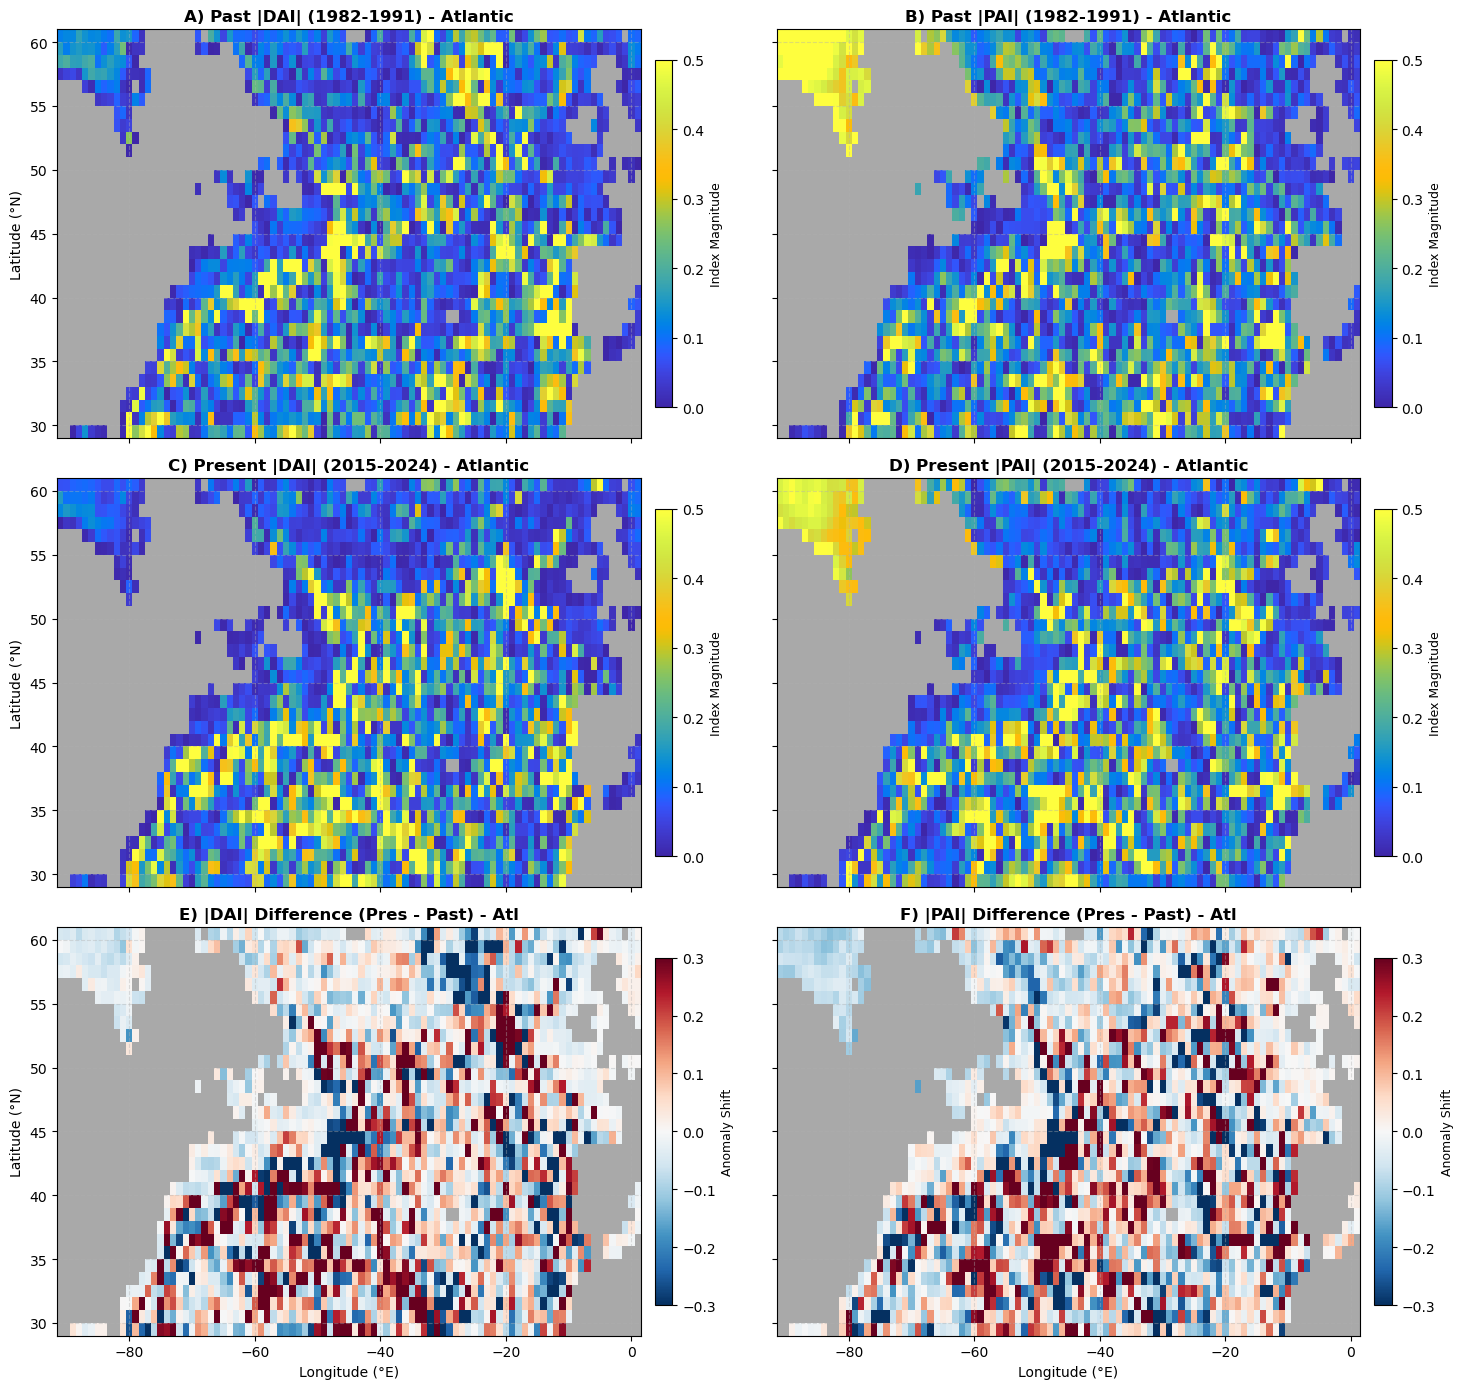

In [26]:
# ==========================================
# 3. Create Custom Parula Colormap & Render North Atlantic Matrix
# ==========================================
print(">>> Visualizing 3x2 Asymmetry Spatial Matrix for North Atlantic...")

# 3.1 Define Custom Parula RGB Data (MATLAB Standard)
from matplotlib.colors import LinearSegmentedColormap

parula_data = [
    [0.2422, 0.1504, 0.6603], [0.2444, 0.1793, 0.7107], [0.2464, 0.2062, 0.7621],
    [0.2464, 0.2336, 0.8166], [0.2406, 0.2631, 0.8735], [0.2243, 0.2974, 0.9328],
    [0.1925, 0.3372, 0.9852], [0.1345, 0.3842, 0.9996], [0.0637, 0.4337, 0.9822],
    [0.0150, 0.4795, 0.9429], [0.0076, 0.5204, 0.8936], [0.0381, 0.5557, 0.8430],
    [0.0886, 0.5855, 0.7960], [0.1437, 0.6111, 0.7523], [0.1966, 0.6338, 0.7115],
    [0.2448, 0.6548, 0.6724], [0.2878, 0.6749, 0.6336], [0.3275, 0.6946, 0.5941],
    [0.3662, 0.7137, 0.5529], [0.4068, 0.7317, 0.5085], [0.4526, 0.7481, 0.4593],
    [0.5061, 0.7621, 0.4035], [0.5694, 0.7725, 0.3396], [0.6433, 0.7785, 0.2666],
    [0.7275, 0.7789, 0.1856], [0.8193, 0.7719, 0.1065], [0.9120, 0.7561, 0.0453],
    [0.9873, 0.7384, 0.0248], [0.9959, 0.7337, 0.0415], [0.9806, 0.7445, 0.0766],
    [0.9507, 0.7628, 0.1171], [0.9150, 0.7854, 0.1557], [0.8809, 0.8105, 0.1895],
    [0.8533, 0.8369, 0.2173], [0.8339, 0.8637, 0.2384], [0.8242, 0.8904, 0.2530],
    [0.8258, 0.9163, 0.2618], [0.8398, 0.9404, 0.2657], [0.8664, 0.9619, 0.2657],
    [0.9044, 0.9800, 0.2625], [0.9515, 0.9933, 0.2570], [0.9965, 0.9977, 0.2443]
]
parula_cmap = LinearSegmentedColormap.from_list('parula', parula_data, N=256)
diff_cmap = 'RdBu_r'

# 3.2 Main Figure Framing
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 14), sharex=True, sharey=True)

# Fixed: Generate meshgrid using specific North Atlantic horizontal coordinates
lon_grid_atl, lat_grid_atl = np.meshgrid(lon_atl, lat_atl)

# Unified Range Setup
vmax_idx = 0.5    
vmax_diff = 0.3

# Fixed: Subplot rendering mapped strictly to North Atlantic computed arrays (_atl)
plots_config = [
    # Row 1: Past State (North Atlantic)
    {'data': dai_past_atl,    'ax': axes[0, 0], 'cmap': parula_cmap, 'vmin': 0.0,         'vmax': vmax_idx,  'title': 'A) Past |DAI| (1982-1991) - Atlantic'},
    {'data': pai_past_atl,    'ax': axes[0, 1], 'cmap': parula_cmap, 'vmin': 0.0,         'vmax': vmax_idx,  'title': 'B) Past |PAI| (1982-1991) - Atlantic'},
    # Row 2: Present State (North Atlantic)
    {'data': dai_present_atl, 'ax': axes[1, 0], 'cmap': parula_cmap, 'vmin': 0.0,         'vmax': vmax_idx,  'title': 'C) Present |DAI| (2015-2024) - Atlantic'},
    {'data': pai_present_atl, 'ax': axes[1, 1], 'cmap': parula_cmap, 'vmin': 0.0,         'vmax': vmax_idx,  'title': 'D) Present |PAI| (2015-2024) - Atlantic'},
    # Row 3: Climate Change Shift (Present - Past)
    {'data': dai_diff_atl,    'ax': axes[2, 0], 'cmap': diff_cmap,   'vmin': -vmax_diff, 'vmax': vmax_diff, 'title': 'E) |DAI| Difference (Pres - Past) - Atl'},
    {'data': pai_diff_atl,    'ax': axes[2, 1], 'cmap': diff_cmap,   'vmin': -vmax_diff, 'vmax': vmax_diff, 'title': 'F) |PAI| Difference (Pres - Past) - Atl'}
]

for p in plots_config:
    ax = p['ax']
    # Fixed: Passing correct Atlantic grid mesh coordinates
    mesh = ax.pcolormesh(lon_grid_atl, lat_grid_atl, p['data'], cmap=p['cmap'], vmin=p['vmin'], vmax=p['vmax'], shading='auto')
    ax.set_title(p['title'], fontsize=12, weight='bold')
    
    cbar = fig.colorbar(mesh, ax=ax, orientation='vertical', pad=0.02, shrink=0.85)
    if 'Difference' in p['title']:
        cbar.set_label('Anomaly Shift', fontsize=9)
    else:
        cbar.set_label('Index Magnitude', fontsize=9)

# Standardize axis decorations for the entire matrix frame
for ax in axes.flatten():
    ax.set_facecolor('darkgray') # Highlights landmask areas beautifully
    ax.grid(True, linestyle='--', alpha=0.4)

# Apply specific labels only to boundary edges to keep plot uncluttered
for row in range(3):
    axes[row, 0].set_ylabel('Latitude (°N)', fontsize=10)
for col in range(2):
    axes[2, col].set_xlabel('Longitude (°E)', fontsize=10)

plt.tight_layout()
plt.show()